# S-DN(ii) — Cash-and-carry basis: Binance perp vs quarterly future

Pre-registration: [README.md](README.md) — hypothesis, frozen rules, decision clauses,
trial count and priors, written and saved **2026-09-08 before any outcome number
existed**. Write-up and clause table: [findings.md](findings.md).

**Headline.** The literal pre-registered verdict is *INCONCLUSIVE (data)* because gate
**D3** fired (15m→1h exact-match 98.80% against a 99.9% threshold). The economics were
nevertheless computed as a recorded deviation and are a **KILL**: net −7.14% annualised
on deployed capital, bootstrap 95% CI [−12.22%, −2.58%], DSR 2.0e−08 at 12 trials.
The convergence is real (+11.72% gross) — the perp funding you pay to hold the hedge
(−17.67%) is larger than it. Fees are only −1.19% of the gap.

Sibling studies S-DN(i) and S-DN(iii) live in
[`studies/notebooks/delta_neutral/`](../delta_neutral/) and are owned by another agent;
this folder is split off so two agents do not write the same directory.

**Execution reality:** p300 has no delivery-futures adapter. Acting on this trade would
be a new venue integration, not a new sleeve. No sleeve and no bot was created.

Pipeline (every cell is read-only on `prod.db`; the whole notebook is ~2 minutes):

1. `basis_carry.py` → the pre-registered run: gates D1/D2/D3, the 12-cell grid, the
   all-15m robustness pass, `results/report.json`.
2. `diagnose_d3.py` → why D3 failed (post-hoc diagnostic of a failed gate).
3. `staleness_check.py` → post-hoc data quality + an independent recomputation of four
   trades from raw SQL.
4. `funding_vs_basis.py` → post-hoc: the population carry identity that explains the
   result without reference to any entry rule.


## 1. The pre-registered run (gates, 12-cell grid, robustness)

In [1]:
%run basis_carry.py

D1 calendar anchors: 8/8 checks, 4/4 distinct -> pass=True


D3 15m->1h: chosen=open_stamped(+2700s) exact_frac=0.988042 (threshold 0.999) -> pass=False
   tiebreak: cd_futures_15m matches the third source; cd_futures_ohlcv is the table carrying the error


panel BTC-CURRENT_QUARTER: 49035 hours 2021-02-03 08:00 .. 2026-09-09 08:00
panel BTC-NEXT_QUARTER: 40636 hours 2021-03-16 07:00 .. 2026-09-09 08:00
panel ETH-CURRENT_QUARTER: 49011 hours 2021-02-04 07:00 .. 2026-09-09 07:00
panel ETH-NEXT_QUARTER: 40635 hours 2021-03-16 07:00 .. 2026-09-09 07:00
D2 roll detection: BTC 22/22, ETH 20/22, worst=0.9091 -> pass=True
term structure: 24 asset/slot/year rows written


grid: 12 pre-registered cells + 12 robustness cells; 245 / 245 trades


D3 impact: 0/19 BTC primary trades have a fill on a mismatching hour

=== LITERAL PRE-REGISTERED VERDICT: INCONCLUSIVE (data) -- clause D3 failed
  pre-registered primary   n= 39  R_ann=-7.1437%  gross=+11.7216%  fees=-1.1943%  funding=-17.6709%
  BTC only                 n= 19  R_ann=-5.9742%  gross=+11.2408%  fees=-1.1416%  funding=-16.0734%
  ETH only                 n= 20  R_ann=-8.3828%  gross=+12.2309%  fees=-1.2502%  funding=-19.3635%
  robustness all-15m       n= 39  R_ann=-7.1437%  gross=+11.7216%  fees=-1.1943%  funding=-17.6709%
  bootstrap 95% CI on primary R_ann: [-12.2196%, -2.5827%]  P(R_ann>0)=0.0008  DSR=1.990e-08
results -> C:\Source\Repos\p300\studies\notebooks\basis_carry\results


## 2. Decision clauses, exactly as frozen in README.md §5

In [2]:
import json
import pandas as pd
pd.set_option('display.width', 240)
pd.set_option('display.max_columns', 60)

rep = json.load(open('results/report.json', encoding='utf-8'))
print('LITERAL PRE-REGISTERED VERDICT :', rep['verdict_literal_prereg'])
print('ECONOMICS IF D3 IS SET ASIDE   :', rep['economics_verdict_ignoring_D3'])
print()
for name, c in rep['clauses'].items():
    m = c.get('measured', c.get('measured_p2_5'))
    m = f'{m:.6g}' if isinstance(m, float) else m
    print(f"  {'FIRES' if c['fired'] else 'no   '}  {name}: measured {m}  vs threshold {c['threshold']}")


LITERAL PRE-REGISTERED VERDICT : INCONCLUSIVE (data) -- clause D3 failed
ECONOMICS IF D3 IS SET ASIDE   : CONCLUDED KILL

  no     D1: measured 4/4 distinct anchors  vs threshold 4/4
  no     D2: measured 0.909091  vs threshold 0.9
  FIRES  D3: measured 0.988042  vs threshold 0.999
  no     S1: measured 39  vs threshold 5
  FIRES  K1: measured -0.071437  vs threshold 0.05
  FIRES  K2: measured -0.122196  vs threshold 0.05
  FIRES  K3: measured 1.99043e-08  vs threshold 0.95


## 3. The primary result and its splits

In [3]:
p = rep['primary']
print(f"pre-registered primary: 8% trigger, CURRENT_QUARTER, BTC+ETH pooled")
print(f"  n_trades          {p['n_trades']}")
print(f"  gross  (annualised on deployed capital)  {p['gross_ann_pooled']:+.4%}")
print(f"  fees                                     {p['fees_ann_pooled']:+.4%}")
print(f"  funding                                  {p['funding_ann_pooled']:+.4%}")
print(f"  ------------------------------------------------")
print(f"  NET  R_ann                               {p['R_ann']:+.4%}")
print()
b = p['bootstrap_R_ann']
print(f"  bootstrap 95% CI on R_ann  [{b['p2_5']:+.4%}, {b['p97_5']:+.4%}]"
      f"   P(R_ann>0)={b['p_above_zero']:.4f}   P(R_ann>=5%)={b['p_above_kill']:.4f}")
print(f"  DSR (n_trials=12)          {p['dsr']['dsr']:.4g}   SR/trade {p['dsr']['sr_per_obs']:+.4f}"
      f"   annualised {p['trade_sharpe_ann']:+.4f}")
print(f"  win rate {p['win_rate']:.1%}   mean hold {p['mean_hold_days']:.1f}d"
      f"   mean entry basis_ann {p['mean_entry_basis_ann']:+.4%}"
      f"   mean residual basis at exit {p['mean_exit_basis']:+.4%}")
print(f"  funding-incomplete trades: {p['n_funding_incomplete']}  (0 = funding fully charged)")
print()
rows = []
for key, lbl in (('primary', 'primary BTC+ETH'), ('primary_btc_only', 'BTC only'),
                 ('primary_eth_only', 'ETH only'),
                 ('primary_alt_all_15m', 'robustness: both perps from 15m')):
    r = rep[key]
    rows.append(dict(cell=lbl, n=r['n_trades'], R_ann=r['R_ann'],
                     gross=r['gross_ann_pooled'], fees=r['fees_ann_pooled'],
                     funding=r['funding_ann_pooled'],
                     boot_p2_5=r['bootstrap_R_ann']['p2_5'], dsr=r['dsr']['dsr']))
sp = pd.DataFrame(rows).set_index('cell')
for c in ('R_ann', 'gross', 'fees', 'funding', 'boot_p2_5'):
    sp[c] = sp[c].map(lambda v: f'{v:+.4%}')
sp['dsr'] = sp['dsr'].map(lambda v: f'{v:.3g}')
display(sp)


pre-registered primary: 8% trigger, CURRENT_QUARTER, BTC+ETH pooled
  n_trades          39
  gross  (annualised on deployed capital)  +11.7216%
  fees                                     -1.1943%
  funding                                  -17.6709%
  ------------------------------------------------
  NET  R_ann                               -7.1437%

  bootstrap 95% CI on R_ann  [-12.2196%, -2.5827%]   P(R_ann>0)=0.0008   P(R_ann>=5%)=0.0000
  DSR (n_trials=12)          1.99e-08   SR/trade -0.4621   annualised -1.2426
  win rate 41.0%   mean hold 63.0d   mean entry basis_ann +12.7860%   mean residual basis at exit +0.3590%
  funding-incomplete trades: 0  (0 = funding fully charged)



,n,R_ann,gross,fees,funding,boot_p2_5,dsr
cell,,,,,,,
primary BTC+ETH,39,-7.1437%,+11.7216%,-1.1943%,-17.6709%,-12.2196%,1.99e-08
BTC only,19,-5.9742%,+11.2408%,-1.1416%,-16.0734%,-11.7743%,1.66e-06
ETH only,20,-8.3828%,+12.2309%,-1.2502%,-19.3635%,-16.3459%,1.17e-05
robustness: both perps from 15m,39,-7.1437%,+11.7216%,-1.1943%,-17.6709%,-12.2196%,1.99e-08


## 4. The full grid — context triggers (5%, 6%) and the NEXT_QUARTER slot

Reported for completeness, **not** as a selection menu. The decision is the 8% CURRENT_QUARTER cell and nothing else. All 12 pre-registered cells and all 12 robustness cells are negative. Note that the NEXT_QUARTER rows nearest breakeven are also the least trustworthy — see section 7.

In [4]:
g = pd.read_csv('results/grid_12_cells.csv')
cols = ['source', 'asset', 'slot', 'trigger', 'cycles_available', 'cycles_closable',
        'n_trades', 'R_ann', 'gross_ann_pooled', 'fees_ann_pooled', 'funding_ann_pooled',
        'win_rate', 'mean_hold_days', 'n_funding_incomplete']
print(f"cells with R_ann >= +5% (the KILL line): {(g.R_ann >= 0.05).sum()} of {len(g)}")
print(f"cells with R_ann > 0:                    {(g.R_ann > 0).sum()} of {len(g)}")
display(g[cols].round(4))


cells with R_ann >= +5% (the KILL line): 0 of 24
cells with R_ann > 0:                    0 of 24


,source,asset,slot,trigger,cycles_available,cycles_closable,n_trades,R_ann,gross_ann_pooled,fees_ann_pooled,funding_ann_pooled,win_rate,mean_hold_days,n_funding_incomplete
0,preregistered,BTC,CURRENT_QUARTER,0.08,23,22,19,-0.0597,0.1124,-0.0114,-0.1607,0.3684,66.4846,0
1,preregistered,BTC,CURRENT_QUARTER,0.06,23,22,22,-0.0506,0.0935,-0.0101,-0.1339,0.4545,75.0568,0
2,preregistered,BTC,CURRENT_QUARTER,0.05,23,22,22,-0.0475,0.0881,-0.0092,-0.1264,0.4091,81.8542,0
3,preregistered,BTC,NEXT_QUARTER,0.08,23,21,19,-0.0120,0.0968,-0.0044,-0.1043,0.5789,170.8925,0
4,preregistered,BTC,NEXT_QUARTER,0.06,23,21,20,-0.0182,0.0853,-0.0045,-0.0990,0.4500,171.9604,0
5,preregistered,BTC,NEXT_QUARTER,0.05,23,21,21,-0.0211,0.0807,-0.0044,-0.0973,0.4762,173.7857,0
6,preregistered,ETH,CURRENT_QUARTER,0.08,23,22,20,-0.0838,0.1223,-0.0125,-0.1936,0.4500,59.6125,0
7,preregistered,ETH,CURRENT_QUARTER,0.06,23,22,21,-0.0676,0.1053,-0.0101,-0.1628,0.3810,73.1845,0
8,preregistered,ETH,CURRENT_QUARTER,0.05,23,22,22,-0.0624,0.1006,-0.0100,-0.1531,0.4545,74.8939,0
9,preregistered,ETH,NEXT_QUARTER,0.08,23,21,18,-0.0100,0.1178,-0.0046,-0.1232,0.6667,168.2292,0


## 5. The 39 pre-registered trades, decomposed

In [5]:
import numpy as np
t = pd.read_csv('results/primary_trades.csv')
liq = pd.read_csv('results/primary_fill_liquidity.csv')
t = t.merge(liq[['asset', 'entry_utc', 'entry_qtr_volume', 'zero_volume_fill']],
            on=['asset', 'entry_utc'], how='left')
show = ['asset', 'entry_utc', 'exit_utc', 'direction', 'hold_days', 'entry_basis_ann',
        'exit_basis', 'gross_ann', 'funding_ann', 'net_ann', 'net', 'entry_qtr_volume']
display(t[show].round(4))

fig_rows = []
t['entry_year'] = pd.to_datetime(t.entry_utc).dt.year
for y, d in t.groupby('entry_year'):
    fig_rows.append(dict(year=int(y), n=len(d),
                         R_ann=365 * d.net.sum() / d.hold_days.sum(),
                         gross=365 * d.gross.sum() / d.hold_days.sum(),
                         funding=365 * d.funding.sum() / d.hold_days.sum()))
fy = pd.DataFrame(fig_rows).set_index('year')
for c in ('R_ann', 'gross', 'funding'):
    fy[c] = fy[c].map(lambda v: f'{v:+.4%}')
display(fy)
print(f"trades clearing +5% annualised: {(t.net_ann >= 0.05).sum()} of {len(t)}")
print(f"R_ann excluding the 2 zero-volume-entry trades: "
      f"{365 * t[~t.zero_volume_fill.astype(bool)].net.sum() / t[~t.zero_volume_fill.astype(bool)].hold_days.sum():+.4%}")


,asset,entry_utc,exit_utc,direction,hold_days,entry_basis_ann,exit_basis,gross_ann,funding_ann,net_ann,net,entry_qtr_volume
0,BTC,2021-02-03 08:00,2021-03-26 07:00,short_qtr_long_perp,50.9583,0.6919,-0.0059,0.7552,-0.9460,-0.2089,-0.0292,4.483
1,ETH,2021-02-04 07:00,2021-03-26 07:00,short_qtr_long_perp,50.0000,0.3728,-0.0014,0.3833,-0.8650,-0.4964,-0.0680,7009.538
2,BTC,2021-03-26 09:00,2021-06-25 07:00,short_qtr_long_perp,90.9167,0.2194,0.0066,0.2024,-0.3224,-0.1268,-0.0316,23.295
3,ETH,2021-03-26 09:00,2021-06-25 07:00,short_qtr_long_perp,90.9167,0.2669,0.0021,0.2571,-0.5599,-0.3118,-0.0777,110.451
4,BTC,2021-06-25 09:00,2021-09-24 07:00,short_qtr_long_perp,90.9167,0.0879,-0.0130,0.1574,-0.1144,0.0337,0.0084,0.000
5,ETH,2021-06-25 09:00,2021-09-24 07:00,short_qtr_long_perp,90.9167,0.0859,0.0125,0.0045,-0.2431,-0.2492,-0.0621,0.000
6,ETH,2021-09-24 10:00,2021-12-31 07:00,short_qtr_long_perp,97.8750,0.0805,-0.0063,0.1113,-0.2496,-0.1470,-0.0394,5558.002
7,BTC,2021-09-26 17:00,2021-12-31 07:00,short_qtr_long_perp,95.5833,0.0801,-0.0032,0.0933,-0.2688,-0.1836,-0.0481,32.442
8,BTC,2021-12-31 09:00,2022-03-25 07:00,short_qtr_long_perp,83.9167,0.1004,0.0041,0.0843,-0.0429,0.0330,0.0076,99.091
9,ETH,2021-12-31 09:00,2022-03-25 07:00,short_qtr_long_perp,83.9167,0.1058,0.0033,0.0941,-0.0355,0.0506,0.0116,810.246


,n,R_ann,gross,funding
year,,,,
2021,10,-14.5098%,+18.0324%,-31.5880%
2022,3,-4.0332%,+7.0970%,-7.9954%
2023,9,-12.5593%,+7.0070%,-18.0576%
2024,8,+1.4335%,+11.4501%,-9.1925%
2025,6,+0.0797%,+6.0001%,-4.7067%
2026,3,-11.6279%,-4.5443%,-0.2164%


trades clearing +5% annualised: 7 of 39
R_ann excluding the 2 zero-volume-entry trades: -6.8532%


## 6. Picture of the whole finding

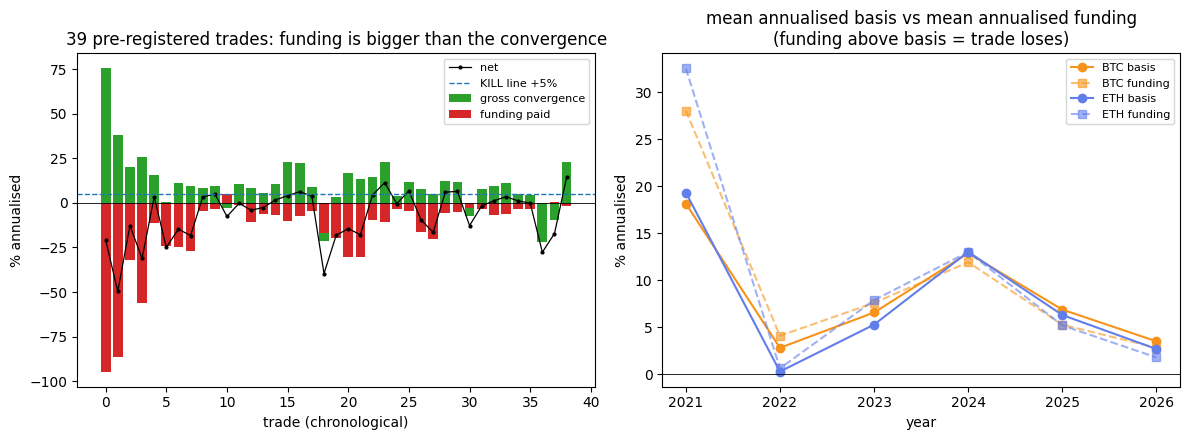

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: per-trade decomposition, sorted by entry
d = t.sort_values('entry_ts').reset_index(drop=True)
x = np.arange(len(d))
axes[0].bar(x, d.gross_ann * 100, color='#2ca02c', label='gross convergence')
axes[0].bar(x, d.funding_ann * 100, color='#d62728', label='funding paid')
axes[0].plot(x, d.net_ann * 100, 'k.-', lw=0.9, ms=4, label='net')
axes[0].axhline(5, color='#1f77b4', ls='--', lw=1, label='KILL line +5%')
axes[0].axhline(0, color='k', lw=0.6)
axes[0].set_ylabel('% annualised'); axes[0].set_xlabel('trade (chronological)')
axes[0].set_title('39 pre-registered trades: funding is bigger than the convergence')
axes[0].legend(fontsize=8)

# right: the two curves, population level
fb = pd.read_csv('results/funding_vs_basis_by_year.csv')
yr = fb[fb.year.astype(str).str.isdigit()].copy()
yr['year'] = yr.year.astype(int)
for asset, c in (('BTC', '#f7931a'), ('ETH', '#627eea')):
    s = yr[yr.asset == asset]
    axes[1].plot(s.year, s.basis_ann_mean * 100, 'o-', color=c, label=f'{asset} basis')
    axes[1].plot(s.year, s.funding_ann_mean * 100, 's--', color=c, alpha=0.6, label=f'{asset} funding')
axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_ylabel('% annualised'); axes[1].set_xlabel('year')
axes[1].set_title('mean annualised basis vs mean annualised funding\n(funding above basis = trade loses)')
axes[1].legend(fontsize=8)
plt.tight_layout()


## 7. Why — the carry identity, independent of any entry rule

At every 8h settlement with at least 7 days to delivery, compare the annualised quarterly basis against the annualised realised perp funding. Their difference is the trade's gross carry before fees. Conditioning on the pre-registered entry state (`basis_ann >= 8%`) makes the carry **worse**, not better: the state that makes the quarterly rich is the state that makes funding expensive.

In [7]:
%run funding_vs_basis.py

asset          year  settlements  basis_ann_mean  funding_ann_mean  carry_mean  carry_median  frac_carry_positive  frac_carry_gt_5pct
  BTC          2021          911        0.181594          0.280573   -0.098979     -0.030060             0.363337            0.214050
  BTC          2022         1011        0.027922          0.040752   -0.012830     -0.028100             0.326409            0.158259
  BTC          2023         1011        0.065558          0.075830   -0.010272     -0.012052             0.380811            0.112760
  BTC          2024         1014        0.128696          0.119060    0.009636      0.017017             0.644970            0.306706
  BTC          2025         1011        0.068626          0.052545    0.016081      0.012835             0.614243            0.208704
  BTC          2026          713        0.034819          0.028060    0.006760      0.001778             0.518934            0.192146
  BTC ALL|basis>=8%         2098        0.156600          0.19


BTC: corr(basis_ann, funding_ann) = +0.7743 over 5671 settlements
  mean carry while basis>=8%: -4.1657% (n=2098 settlements); block-bootstrap 95% CI [-8.2120%, -0.9508%]; P(mean carry > 0) = 0.0032



ETH: corr(basis_ann, funding_ann) = +0.7279 over 5667 settlements
  mean carry while basis>=8%: -6.8933% (n=1816 settlements); block-bootstrap 95% CI [-11.9337%, -2.8738%]; P(mean carry > 0) = 0.0000
results -> C:\Source\Repos\p300\studies\notebooks\basis_carry\results


In [8]:
fb = pd.read_csv('results/funding_vs_basis_by_year.csv')
display(fb.round(4))
ci = pd.read_csv('results/funding_vs_basis_ci.csv')
print('\ncarry = basis_ann - funding_ann, measured while the pre-registered 8% trigger is ON:')
display(ci.round(4))


,asset,year,settlements,basis_ann_mean,funding_ann_mean,carry_mean,carry_median,frac_carry_positive,frac_carry_gt_5pct
0,BTC,2021,911,0.1816,0.2806,-0.0990,-0.0301,0.3633,0.2141
1,BTC,2022,1011,0.0279,0.0408,-0.0128,-0.0281,0.3264,0.1583
2,BTC,2023,1011,0.0656,0.0758,-0.0103,-0.0121,0.3808,0.1128
3,BTC,2024,1014,0.1287,0.1191,0.0096,0.0170,0.6450,0.3067
4,BTC,2025,1011,0.0686,0.0525,0.0161,0.0128,0.6142,0.2087
5,BTC,2026,713,0.0348,0.0281,0.0068,0.0018,0.5189,0.1921
6,BTC,ALL|basis>=8%,2098,0.1566,0.1983,-0.0417,-0.0001,0.4990,0.2240
7,BTC,ALL,5671,0.0855,0.1000,-0.0146,-0.0039,0.4745,0.1989
8,ETH,2021,908,0.1933,0.3256,-0.1323,-0.0399,0.3216,0.1619
9,ETH,2022,1011,0.0027,0.0061,-0.0034,-0.0361,0.3462,0.2047



carry = basis_ann - funding_ann, measured while the pre-registered 8% trigger is ON:


,asset,corr_basis_funding,n_settlements_hot,mean_carry_hot,ci_lo,ci_hi,p_mean_carry_gt_0
0,BTC,0.7743,2098,-0.0417,-0.0821,-0.0095,0.0032
1,ETH,0.7279,1816,-0.0689,-0.1193,-0.0287,0.0000


## 8. Data quality, verification, and the failed D3 gate

`diagnose_d3.py` and `staleness_check.py` are **post-hoc** diagnostics written after the pre-registered run. They change no rule and move no threshold.

In [9]:
%run diagnose_d3.py

overlap hours       : 61383
exact (atol 1e-9)   : 0.988042   n_mismatch=734
  |diff| <= 1e-08   : 0.988042
  |diff| <= 1e-06   : 0.988042
  |diff| <= 0.0001  : 0.988042
  |diff| <= 0.01    : 0.988042
  |diff| <= 0.1     : 0.992050
  |diff| <= 1.0     : 0.998908
  |diff| <= 10.0    : 0.999120
  rel   <= 1e-09   : 0.988042
  rel   <= 1e-08   : 0.988042
  rel   <= 1e-07   : 0.988042
  rel   <= 1e-06   : 0.993516
  rel   <= 1e-05   : 0.998876
  rel   <= 0.0001  : 0.999120
  rel   <= 0.001   : 0.999690

mismatches by year:
        n       med_rel   max_rel
year                             
2021    3  2.549174e-03  0.008163
2022    1  3.546720e-04  0.000355
2023    4  1.300145e-05  0.000034
2024   21  1.512141e-06  0.001767
2025  467  9.007889e-07  0.008496
2026  238  1.408244e-06  0.006877

exact-fraction by year:
         n  n_bad  exact_frac
year                         
2019  2743    0.0    1.000000
2020  8784    0.0    1.000000
2021  8760    3.0    0.999658
2022  8760    1.0    0.999886

In [10]:
%run staleness_check.py

staleness by asset/slot/year
asset            slot  year  hours  frac_zero_volume  frac_repeated_close  median_volume
  BTC CURRENT_QUARTER  2021   7960          0.000503             0.001005        59.5805
  BTC CURRENT_QUARTER  2022   8760          0.000000             0.000799        82.5330
  BTC CURRENT_QUARTER  2023   8760          0.000000             0.000799        41.6525
  BTC CURRENT_QUARTER  2024   8784          0.000000             0.000114        17.9795
  BTC CURRENT_QUARTER  2025   8760          0.000000             0.000228         7.2420
  BTC CURRENT_QUARTER  2026   6033          0.000000             0.000332         5.4560
  BTC    NEXT_QUARTER  2021   6977          0.907267             0.907267         0.0000
  BTC    NEXT_QUARTER  2022   5523          0.903857             0.904038         0.0000
  BTC    NEXT_QUARTER  2023   4559          0.236236             0.236894        11.5540
  BTC    NEXT_QUARTER  2024   8784          0.000000             0.000455        


term structure restricted to entry-eligible hours (dtd >= 7d):
asset            slot  year  hours  basis_ann_mean  basis_ann_median  basis_ann_sd  basis_ann_p05  basis_ann_p95  frac_ge_8pct  frac_ge_6pct  frac_ge_5pct  frac_le_m8pct
  BTC CURRENT_QUARTER  2021   7288        0.181405          0.133389      0.144218       0.037296       0.485562      0.712541      0.840148      0.890368       0.000274
  BTC CURRENT_QUARTER  2022   8088        0.028071          0.026658      0.025119      -0.018248       0.073291      0.037339      0.079871      0.163205       0.000000
  BTC CURRENT_QUARTER  2023   8088        0.065648          0.059048      0.026015       0.029700       0.109113      0.285856      0.487141      0.700915       0.000000
  BTC CURRENT_QUARTER  2024   8112        0.128595          0.112472      0.058319       0.068910       0.254351      0.874877      0.986440      0.999630       0.000000
  BTC CURRENT_QUARTER  2025   8088        0.068613          0.063367      0.022679    

In [11]:
print('quarterly print staleness — NEXT_QUARTER before 2024 is a repeated (zero-volume) print:')
display(pd.read_csv('results/staleness_by_year.csv').round(4))
print('\nterm structure restricted to entry-eligible hours (dtd >= 7d) — use this one, not the'
      ' unrestricted file, whose sd is the 365/dtd term exploding near expiry:')
d7 = pd.read_csv('results/basis_term_structure_dtd7.csv')
display(d7[d7.slot == 'CURRENT_QUARTER'].round(4))
print('\nindependent recomputation of 4 sample trades from raw SQL (no shared code):')
display(pd.read_csv('results/manual_trade_check.csv').round(10))
print('\nD3 gate evidence — by-year exact-match fraction of the 15m->1h reconstruction:')
display(pd.read_csv('results/d3_diagnostic.csv').round(6))
print('D3 third-source tiebreak:', json.dumps(rep['D3']['tiebreak_third_source'], indent=1))
print('D3 impact on the primary :', json.dumps(rep['d3_impact_on_primary'], indent=1))


quarterly print staleness — NEXT_QUARTER before 2024 is a repeated (zero-volume) print:


,asset,slot,year,hours,frac_zero_volume,frac_repeated_close,median_volume
0,BTC,CURRENT_QUARTER,2021,7960,0.0005,0.0010,59.5805
1,BTC,CURRENT_QUARTER,2022,8760,0.0000,0.0008,82.5330
2,BTC,CURRENT_QUARTER,2023,8760,0.0000,0.0008,41.6525
3,BTC,CURRENT_QUARTER,2024,8784,0.0000,0.0001,17.9795
4,BTC,CURRENT_QUARTER,2025,8760,0.0000,0.0002,7.2420
5,BTC,CURRENT_QUARTER,2026,6033,0.0000,0.0003,5.4560
6,BTC,NEXT_QUARTER,2021,6977,0.9073,0.9073,0.0000
7,BTC,NEXT_QUARTER,2022,5523,0.9039,0.9040,0.0000
8,BTC,NEXT_QUARTER,2023,4559,0.2362,0.2369,11.5540
9,BTC,NEXT_QUARTER,2024,8784,0.0000,0.0005,10.6600



term structure restricted to entry-eligible hours (dtd >= 7d) — use this one, not the unrestricted file, whose sd is the 365/dtd term exploding near expiry:


,asset,slot,year,hours,basis_ann_mean,basis_ann_median,basis_ann_sd,basis_ann_p05,basis_ann_p95,frac_ge_8pct,frac_ge_6pct,frac_ge_5pct,frac_le_m8pct
0,BTC,CURRENT_QUARTER,2021,7288,0.1814,0.1334,0.1442,0.0373,0.4856,0.7125,0.8401,0.8904,0.0003
1,BTC,CURRENT_QUARTER,2022,8088,0.0281,0.0267,0.0251,-0.0182,0.0733,0.0373,0.0799,0.1632,0.0000
2,BTC,CURRENT_QUARTER,2023,8088,0.0656,0.0590,0.0260,0.0297,0.1091,0.2859,0.4871,0.7009,0.0000
3,BTC,CURRENT_QUARTER,2024,8112,0.1286,0.1125,0.0583,0.0689,0.2544,0.8749,0.9864,0.9996,0.0000
4,BTC,CURRENT_QUARTER,2025,8088,0.0686,0.0634,0.0227,0.0428,0.1213,0.2271,0.5810,0.8210,0.0000
5,BTC,CURRENT_QUARTER,2026,5697,0.0351,0.0384,0.0138,0.0105,0.0519,0.0019,0.0119,0.0781,0.0000
12,ETH,CURRENT_QUARTER,2021,7265,0.1937,0.1439,0.1664,0.0386,0.5519,0.7337,0.8425,0.8983,0.0003
13,ETH,CURRENT_QUARTER,2022,8088,0.0024,0.0119,0.0567,-0.1347,0.0725,0.0370,0.0867,0.1248,0.0989
14,ETH,CURRENT_QUARTER,2023,8088,0.0527,0.0494,0.0265,0.0149,0.0963,0.1306,0.3285,0.4890,0.0000
15,ETH,CURRENT_QUARTER,2024,8112,0.1301,0.1135,0.0643,0.0632,0.2620,0.8024,0.9661,0.9958,0.0000



independent recomputation of 4 sample trades from raw SQL (no shared code):


,asset,entry_utc,exit_utc,script_net,manual_net,abs_diff,script_gross,manual_gross,script_funding,manual_funding,settlements_found,settlements_expected
0,BTC,2021-02-03 08:00,2021-03-26 07:00,-0.029169,-0.029169,0.0,0.105432,0.105432,-0.132071,-0.132071,152,152
1,BTC,2023-02-20 11:00,2023-03-31 07:00,-0.002758,-0.002758,0.0,0.005969,0.005969,-0.006607,-0.006607,116,116
2,BTC,2024-09-27 14:00,2024-12-27 07:00,-0.023688,-0.023688,0.0,0.019591,0.019591,-0.040832,-0.040832,272,272
3,ETH,2026-06-16 15:00,2026-06-26 07:00,0.003791,0.003791,0.0,0.006068,0.006068,-0.000391,-0.000391,29,29



D3 gate evidence — by-year exact-match fraction of the 15m->1h reconstruction:


,year,n,n_bad,exact_frac
0,2019,2743,0.0,1.000000
1,2020,8784,0.0,1.000000
2,2021,8760,3.0,0.999658
3,2022,8760,1.0,0.999886
4,2023,8760,4.0,0.999543
5,2024,8784,21.0,0.997609
6,2025,8760,467.0,0.946689
7,2026,6032,238.0,0.960544


D3 third-source tiebreak: {
 "available": true,
 "overlap": 21014,
 "n_mismatch": 719,
 "n_1h_closer_to_tv": 2,
 "n_15m_closer_to_tv": 717,
 "median_abs_1h_minus_tv": 0.10000000000582077,
 "median_abs_15m_minus_tv": 0.0,
 "verdict": "cd_futures_15m matches the third source; cd_futures_ohlcv is the table carrying the error"
}
D3 impact on the primary : {
 "btc_trades": 19,
 "n_fills_checked": 38,
 "n_trades_touching_a_mismatched_hour": 0,
 "examples": []
}
